# PMF, CDF, Joint Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Nazhin Nikkhahbahrami

*SID:* 810102530

The objective of this notebook is to understand the concepts of PMF and CDF and joint distribution.

In [25]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parameters

In [26]:
num_counters = 1
arrival_rate = 5  # customers per minute
service_rate = 6 # customers per minute
simulation_time = 10000  # minutes

## Simulation

In [27]:
def simulate_queue_system():
    """
    Simulates a queue system with customers arriving at service counters, waiting for service, and being served.

    This function defines the customer behavior and the setup of the simulation environment. It initializes the simulation environment, sets up the service counters, and continuously generates customer arrivals based on specified arrival and service rates. The function runs the simulation until the specified simulation time and returns the recorded wait times, arrival times, and service times of the customers.

    Returns:
        tuple: A tuple containing three lists - wait_times, arrival_times, and service_times, which record the respective times for each customer in the simulation.
    """

    def customer(
        env: simpy.Environment,
        name: str,
        counter: simpy.Resource,
        service_time: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Simulates a customer arriving at a service counter, waiting for service, and then being served.

        Args:
            env (simpy.Environment): The simulation environment.
            name (str): The name of the customer.
            counter (simpy.Resource): The service counter resource.
            service_time (float): The time it takes to serve the customer.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Process: The process of the customer being served.
        """
        arrival_time = env.now
        arrival_times.append(arrival_time)
        with counter.request() as req:
            yield req
            yield env.timeout(service_time)
            service_times.append(service_time)
            wait_time = env.now - arrival_time
            wait_times.append(wait_time)

    def setup(
        env: simpy.Environment,
        num_counters: int,
        arrival_rate: float,
        service_rate: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Sets up the simulation environment with a specified number of service counters and customer arrival and service rates.

        Args:
            env (simpy.Environment): The simulation environment.
            num_counters (int): The number of service counters available.
            arrival_rate (float): The rate at which customers arrive.
            service_rate (float): The rate at which customers are served.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Timeout: The timeout event for the next customer arrival.
        """
        counter = simpy.Resource(env, num_counters)
        while True:
            yield env.timeout(np.random.exponential(1 / arrival_rate))
            service_time = np.random.exponential(1 / service_rate)
            env.process(
                customer(
                    env,
                    "Customer",
                    counter,
                    service_time,
                    wait_times,
                    arrival_times,
                    service_times,
                )
            )

    while True:
        env = simpy.Environment()
        wait_times = []
        arrival_times = []
        service_times = []
        env.process(
            setup(
                env,
                num_counters,
                arrival_rate,
                service_rate,
                wait_times,
                arrival_times,
                service_times,
            )
        )
        env.run(until=simulation_time)

        if len(wait_times) == len(arrival_times) == len(service_times):
            return wait_times, arrival_times, service_times
        
wait_times, arrival_times, service_times = simulate_queue_system()

## Plot the RVs Distributions

Text(0.5, 1.0, 'KDE = 10')

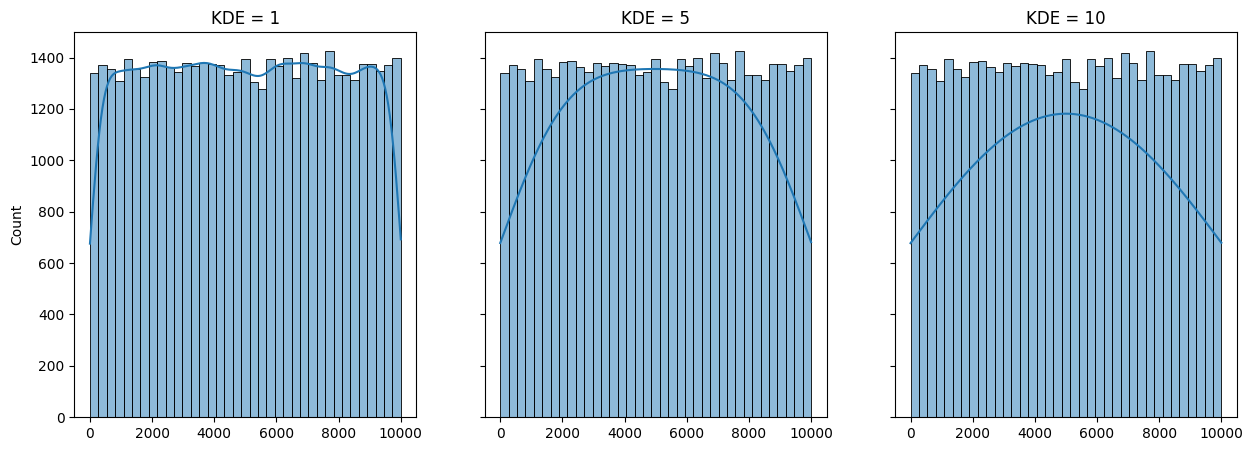

In [28]:
######################  TODO  ########################
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
sns.histplot(data=arrival_times, kde=True, kde_kws={'bw_adjust':1}, ax = axes[0])
axes[0].set_title("KDE = 1")
sns.histplot(data=arrival_times, kde=True, kde_kws={'bw_adjust':5}, ax = axes[1])
axes[1].set_title("KDE = 5")
sns.histplot(data=arrival_times, kde=True, kde_kws={'bw_adjust':10}, ax = axes[2])
axes[2].set_title("KDE = 10")
######################  TODO  ########################

bedoon dashtan kde tanha soton hay tozi ra darim va kde komak mikonad ke betavanim chegali tozi ra behtar peyvaste bebinim. ba taghir meghda kde masalan az 1 be 5 va 10 nemoodar ha neshan midahad ke kde kamtar namayesh behtari az chegali haste darad.

Text(0.5, 1.0, 'KDE = 10')

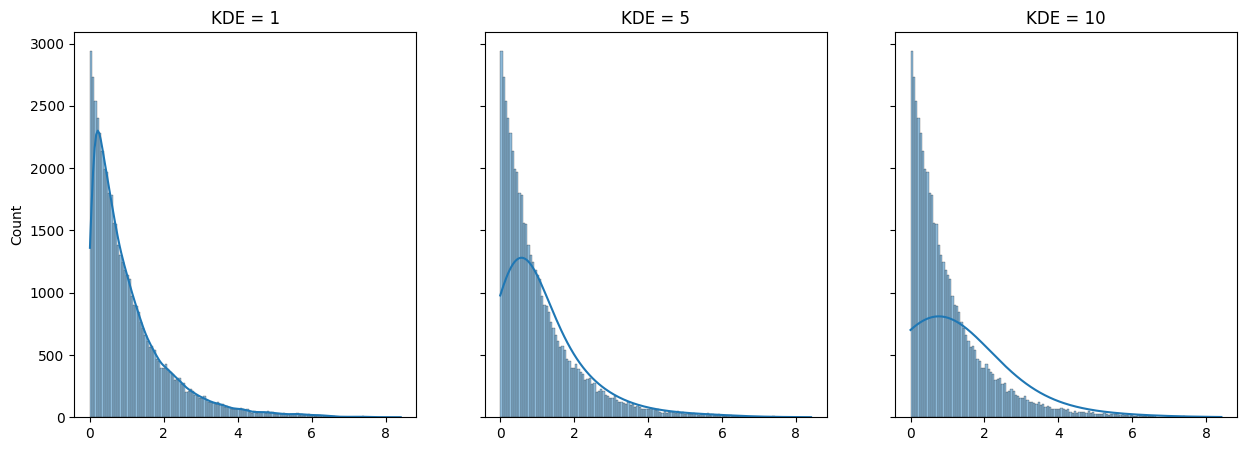

In [29]:
######################  TODO  ########################
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
sns.histplot(data=wait_times, kde=True, kde_kws={'bw_adjust':1}, ax = axes[0])
axes[0].set_title("KDE = 1")
sns.histplot(data=wait_times, kde=True, kde_kws={'bw_adjust':5}, ax = axes[1])
axes[1].set_title("KDE = 5")
sns.histplot(data=wait_times, kde=True, kde_kws={'bw_adjust':10}, ax = axes[2])
axes[2].set_title("KDE = 10")
######################  TODO  ########################

baz inja kde kamtar noghat tarakom ra behtar neshan midahad va khamidegi dar noghat chegal tar ast. dar ghesmat hay aval nemoodar tarakom bishtari darad

Text(0.5, 1.0, 'KDE = 10')

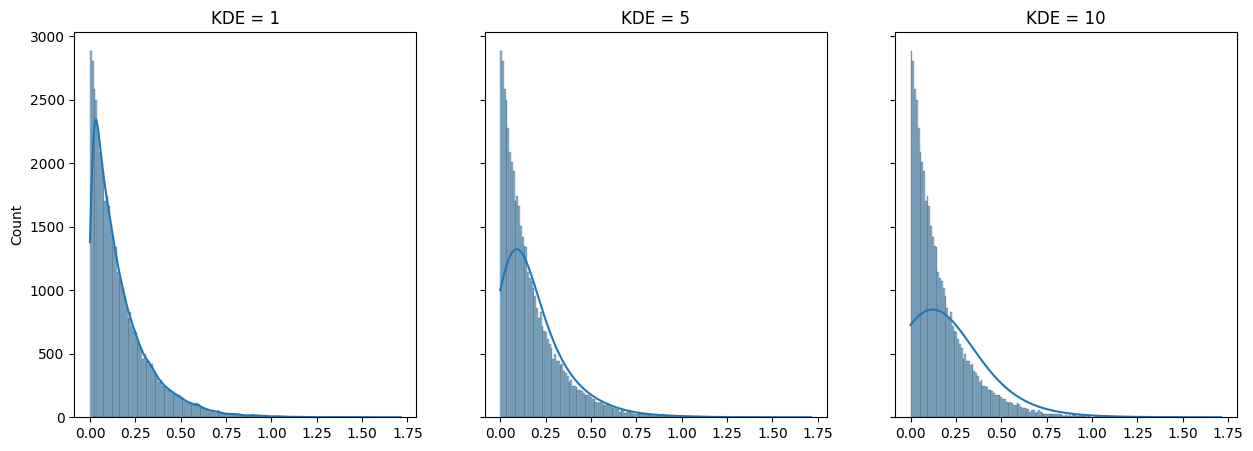

In [30]:
######################  TODO  ########################
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
sns.histplot(data=service_times, kde=True, kde_kws={'bw_adjust':1}, ax = axes[0])
axes[0].set_title("KDE = 1")
sns.histplot(data=service_times, kde=True, kde_kws={'bw_adjust':5}, ax = axes[1])
axes[1].set_title("KDE = 5")
sns.histplot(data=service_times, kde=True, kde_kws={'bw_adjust':10}, ax = axes[2])
axes[2].set_title("KDE = 10")
######################  TODO  ########################

mesl 2 ghesmat ghabl.

## Plot the Joint Distributions

**Note:** Use `sns.jointplot` to plot the joint distributions

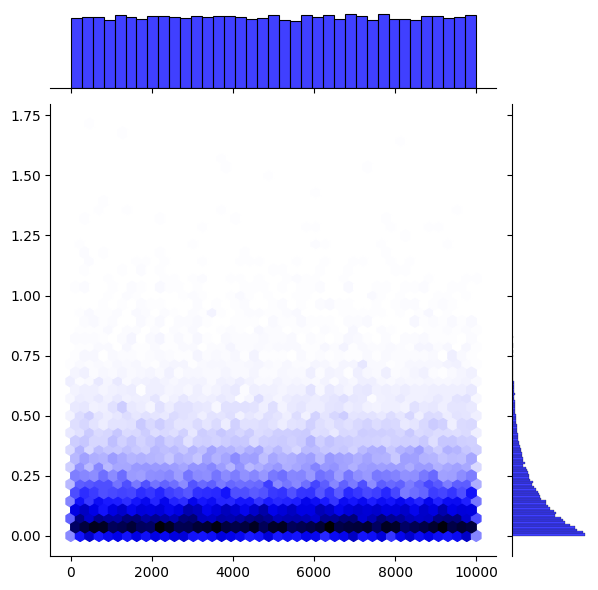

In [31]:
######################  TODO  ########################
sns.jointplot(x=arrival_times, y=service_times, kind="hex", color="blue")
######################  TODO  ########################

baray barressi corolotioin dar yek nemoodar ba ham rasm mikonim chon afzayesh ya kahesh arrival tasiri rooy digari nadarad, corolation+,- nadarad. agar scatter bood masalan khat ba shib yeksan dar hame noghat bood va agar ba kde mizadim beyzi hay too dar too payvaste bood va ba afzayesh meghdar ha fasele beyzi ha bishtar mishod.

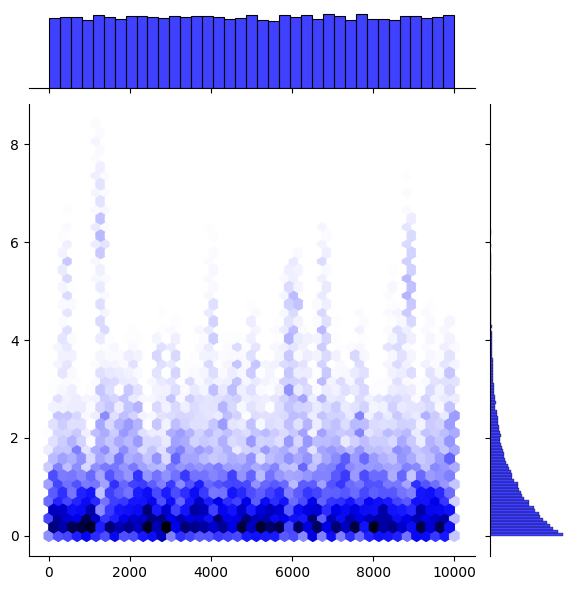

In [32]:
######################  TODO  ########################
sns.jointplot(x=arrival_times, y=wait_times, kind="hex", color="blue")
######################  TODO  ########################

## Analysis of Joint Distributions

TODO

batavajoh be shekl do nemoodar ba ham taghir mokonand(kahesh va afzayesh be ham marboot ast) va correlation - ast. yani agar kde dood beyzi ha joda shode va napeyvaste bood.

## Scatter Plot and Correlation

<Axes: >

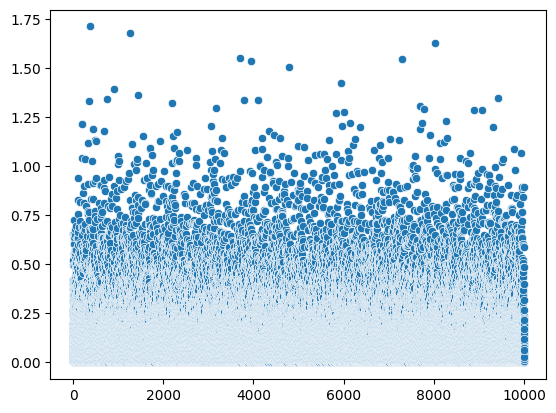

In [33]:
######################  TODO  ########################
# Scatter Plot of Arrival and Service Times
sns.scatterplot(x=arrival_times, y=service_times)
######################  TODO  ########################

chon nemoodar scatter khat nist pas correlation - darim va be ham vabaste mibashand.

## Calculating `total_times`

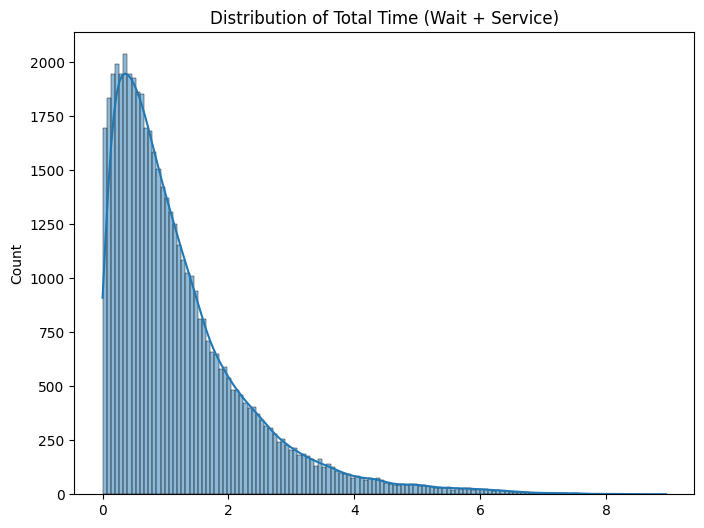

In [34]:
######################  TODO  ########################
# Distribution of Total Time Spent in the System
total_times = []
for i in range(len(wait_times)):
    total_times.append(wait_times[i] + service_times[i])
plt.figure(figsize=(8, 6))
sns.histplot(total_times, kde=True)
plt.title("Distribution of Total Time (Wait + Service)")
plt.show()
######################  TODO  ########################

baray mohasebe total_time, tamami ozv hay wait_time va service_time ra ba ham jam mikonim.
bar asas convolution nemoodar kol namayi ast. inja baray zaman kol nabayad arrival_times yani zaman residan ra mohasebe konim chon takhir va service dehi dar in zaman nadarad va tanha sevice_time va wait_time jam mishavand.

## Conditional Wait Times

 dune dune zaman ha ra dar araye zakhire konad va be plot bedahad. 

Text(0.5, 1.0, 'Total Times Conditional Distribution')

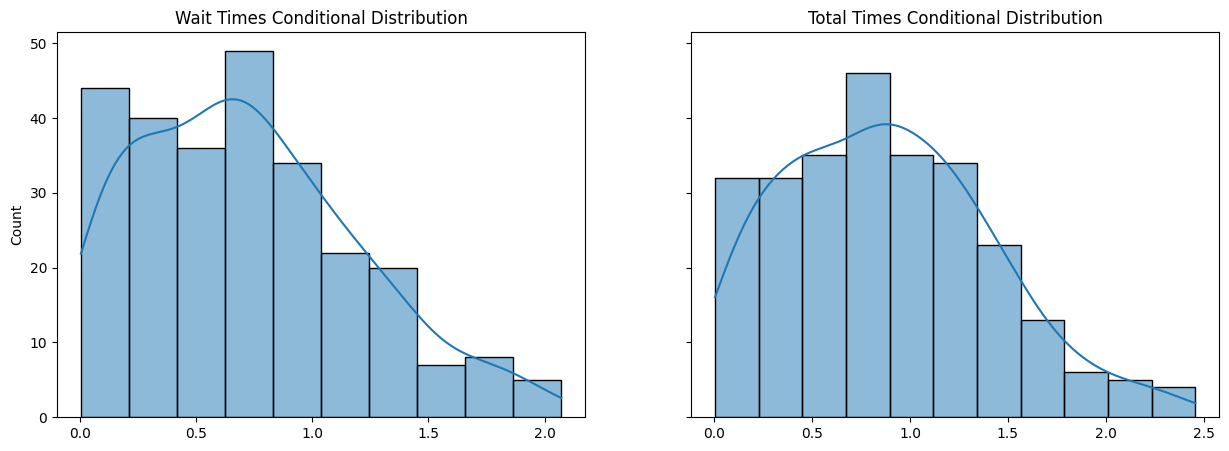

In [37]:
######################  TODO  ########################
# Conditional Distribution of Waiting Times (Arrival Time < 50)
under_50_wait_times = [wait_times[i] for i in range(len(arrival_times)) if arrival_times[i] < 50]
under_50_total_times = [total_times[i] for i in range(len(arrival_times)) if arrival_times[i] < 50]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.histplot(data=under_50_wait_times, kde=True, ax = axes[0])
axes[0].set_title("Wait Times Conditional Distribution")
sns.histplot(data=under_50_total_times, kde=True, ax = axes[1])
axes[1].set_title("Total Times Conditional Distribution")
######################  TODO  ########################

kde taghriban shabih ham ast.